In [41]:
#IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, KFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, TargetEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

# Style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Library berhasil diimpor!')


✅ Library berhasil diimpor!


In [42]:
#LOAD DATASET
FILE_PATH = r'D:\DATA ANALYST-DATA SCIENTIST\MY PROJECT 2025\MARKETING FILE PROJECT\Analisis Produk Gitar Elektrik Harga, Brand, dan Rating di Tokopedia\dataset_tokopedia-scraper_2026-04-28_04-41-59-431.csv'

df_raw = pd.read_csv(FILE_PATH)

print(f'   Dataset berhasil dimuat!')
print(f'   Jumlah baris   : {df_raw.shape[0]:,}')
print(f'   Jumlah kolom   : {df_raw.shape[1]:,}')
print(f'   Memori         : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')

   Dataset berhasil dimuat!
   Jumlah baris   : 100
   Jumlah kolom   : 44
   Memori         : 231.2 KB


In [43]:
#PREVIEW DATA
df_raw.head()

,badge/id,badge/title,badge/url,category/breadcrumb,category/id,category/name,freeShipping/url,id,labelGroups/0/title,labelGroups/1/title,...,shop/tier,shop/ttsSellerID,shop/url,stock/maxOrder,stock/minOrder,stock/number,stock/sold,stock/ttsSKUID,ttsProductID,url
0,4,Kab. Tangerang,https://p16-images-comn-sg.tokopedia-static.ne...,film-musik/gitar-bass/gitar-elektrik,57,Film & Musik,NaN,13086582183,1rb+ terjual,double_date_4,...,2,7495671279332723121,https://www.tokopedia.com/benstonmusic,458,1,458,1897.0,1729602007747495345,1729602096687252913,https://www.tokopedia.com/benstonmusic/benston...
1,2,Jakarta Barat,NaN,film-musik/gitar-bass/gitar-elektrik,57,Film & Musik,NaN,424712783,100+ terjual,double_date_4,...,1,7495811584458918464,https://www.tokopedia.com/gitarjakarta,99869,1,99869,159.0,1729812676487317056,1729812676487251520,https://www.tokopedia.com/gitarjakarta/gitar-e...
2,4,Jakarta Barat,https://p16-images-comn-sg.tokopedia-static.ne...,film-musik/gitar-bass/gitar-elektrik,57,Film & Musik,NaN,100709793175,80+ terjual,double_date_4,...,2,7495313222517492495,https://www.tokopedia.com/donner-official-store,9,1,9,83.0,1731847652777166607,1731847656801797903,https://www.tokopedia.com/donner-official-stor...
3,2,Jakarta Barat,NaN,film-musik/gitar-bass/gitar-elektrik,57,Film & Musik,NaN,4905974288,100+ terjual,double_date_4,...,1,7495811584458918464,https://www.tokopedia.com/gitarjakarta,55,1,55,104.0,1729984234233562688,1729984234233431616,https://www.tokopedia.com/gitarjakarta/gitar-e...
4,2,Kab. Sleman,NaN,film-musik/gitar-bass/gitar-elektrik,57,Film & Musik,NaN,100325829748,90+ terjual,double_date_4,...,1,7494956723600853529,https://www.tokopedia.com/rockindojogja-712,10,1,10,90.0,1729704430610123289,1729680998541265433,https://www.tokopedia.com/rockindojogja-712/gi...


In [44]:
# INFO & STATISTIK DESKRIPTIF
print('=== INFO DATASET ===')
df_raw.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   badge/id                  100 non-null    int64  
 1   badge/title               100 non-null    object 
 2   badge/url                 23 non-null     object 
 3   category/breadcrumb       100 non-null    object 
 4   category/id               100 non-null    int64  
 5   category/name             100 non-null    object 
 6   freeShipping/url          0 non-null      float64
 7   id                        100 non-null    int64  
 8   labelGroups/0/title       100 non-null    object 
 9   labelGroups/1/title       100 non-null    object 
 10  labelGroups/2/title       97 non-null     object 
 11  labelGroups/3/title       75 non-null     object 
 12  labelGroups/4/title       75 non-null     object 
 13  labelGroups/5/title       41 non-null     obj

In [45]:
#  PILIH KOLOM RELEVAN & RENAME
COLS_SELECTED = [
    'name',                      # Nama produk
    'shop/name',                 # Nama toko
    'shop/city',                 # Kota/lokasi toko
    'shop/tier',                 # Tier toko (1=Power Merchant, 2=Official Store)
    'price/number',              # Harga (numerik)
    'price/discountPercentage',  # Diskon %
    'rating',                    # Rating produk
    'meta/countReview',          # Jumlah review
    'stock/sold',                # Jumlah terjual → TARGET
    'stock/number',              # Stok tersedia
]

df = df_raw[COLS_SELECTED].copy()
df.columns = ['name', 'shop_name', 'city', 'shop_tier',
              'price', 'discount_pct', 'rating',
              'count_review', 'sold', 'stock']

print(f'✅ Kolom terpilih: {df.columns.tolist()}')
print(f'   Shape: {df.shape}')

✅ Kolom terpilih: ['name', 'shop_name', 'city', 'shop_tier', 'price', 'discount_pct', 'rating', 'count_review', 'sold', 'stock']
   Shape: (100, 10)


In [46]:
# PEMBERSIHAN DATA


# 1) Hapus baris di mana target (sold) kosong
df.dropna(subset=['sold'], inplace=True)

# 2) Isi missing numerik dengan median
for col in ['rating', 'count_review', 'discount_pct', 'stock']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'   {col}: filled NA dengan median = {median_val:.2f}')

# 3) Isi missing kategorik dengan 'Unknown'
for col in ['city', 'shop_name']:
    df[col].fillna('Unknown', inplace=True)

# 4) Pastikan tipe data benar
df['sold']         = df['sold'].astype(int)
df['price']        = df['price'].astype(float)
df['rating']       = df['rating'].astype(float)
df['count_review'] = df['count_review'].astype(float)
df['shop_tier']    = df['shop_tier'].astype(int)

# 5) Hapus outlier ekstrem pada 'sold' (> 3 std)
z_sold = (df['sold'] - df['sold'].mean()) / df['sold'].std()
before = len(df)
df = df[z_sold.abs() <= 3]
print(f'\n   Baris sebelum hapus outlier sold: {before}')
print(f'   Baris setelah hapus outlier sold : {len(df)}')
print(f'\n✅ Setelah pembersihan: {df.shape}')

   rating: filled NA dengan median = 4.90
   count_review: filled NA dengan median = 0.00
   discount_pct: filled NA dengan median = 0.00
   stock: filled NA dengan median = 10.00

   Baris sebelum hapus outlier sold: 96
   Baris setelah hapus outlier sold : 94

✅ Setelah pembersihan: (94, 10)


In [47]:
# FEATURE ENGINEERING


# 1) Segmen Harga
bins_price   = [0, 500_000, 1_000_000, 1_500_000, 2_000_000, float('inf')]
labels_price = ['< 500K', '500K–1Jt', '1Jt–1.5Jt', '1.5Jt–2Jt', '> 2Jt']
df['price_segment'] = pd.cut(df['price'], bins=bins_price,
                              labels=labels_price, right=False)

# 2) Segmen Rating
bins_rating   = [0, 3.0, 4.0, 4.5, 5.01]
labels_rating = ['< 3.0', '3.0–4.0', '4.0–4.5', '4.5–5.0']
df['rating_segment'] = pd.cut(df['rating'], bins=bins_rating,
                               labels=labels_rating, right=False)

# 3) Flag ada diskon
df['has_discount'] = (df['discount_pct'] > 0).astype(int)

# 4) Log transform sold (distribusi lebih normal → modeling lebih stabil)
df['log_sold'] = np.log1p(df['sold'])

# 5) Fitur tambahan untuk meningkatkan akurasi model
#    — price per rating (value for money)
df['price_per_rating'] = df['price'] / (df['rating'] + 0.001)
#    — review density (review per sold)
df['review_density'] = df['count_review'] / (df['sold'] + 1)
#    — log price (mengurangi skewness)
df['log_price'] = np.log1p(df['price'])
#    — log stock
df['log_stock'] = np.log1p(df['stock'])
#    — rating × log_price interaksi
df['rating_x_logprice'] = df['rating'] * df['log_price']

print('✅ Feature Engineering selesai!')
df[['price_segment', 'rating_segment', 'has_discount', 'log_sold']].head()


✅ Feature Engineering selesai!


,price_segment,rating_segment,has_discount,log_sold
1,500K–1Jt,4.5–5.0,0,5.075174
2,1.5Jt–2Jt,4.5–5.0,0,4.430817
3,1Jt–1.5Jt,4.5–5.0,0,4.653960
4,1Jt–1.5Jt,4.5–5.0,0,4.510860
5,> 2Jt,4.5–5.0,0,3.713572


In [48]:
#  STATISTIK DESKRIPTIF UTAMA


desc_cols = ['price', 'rating', 'count_review', 'sold', 'stock', 'discount_pct']
df[desc_cols].describe().round(2).style.background_gradient(cmap='Blues')

,price,rating,count_review,sold,stock,discount_pct
count,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000
mean,1382161.110000,4.700000,0.000000,34.180000,8012.870000,0.000000
std,579203.570000,0.580000,0.000000,50.850000,26319.680000,0.000000
min,349899.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,1091250.000000,4.700000,0.000000,4.250000,3.000000,0.000000
50%,1300500.000000,4.900000,0.000000,13.500000,10.000000,0.000000
75%,1550000.000000,5.000000,0.000000,31.500000,20.750000,0.000000
max,3408899.000000,5.000000,0.000000,285.000000,99999.000000,0.000000


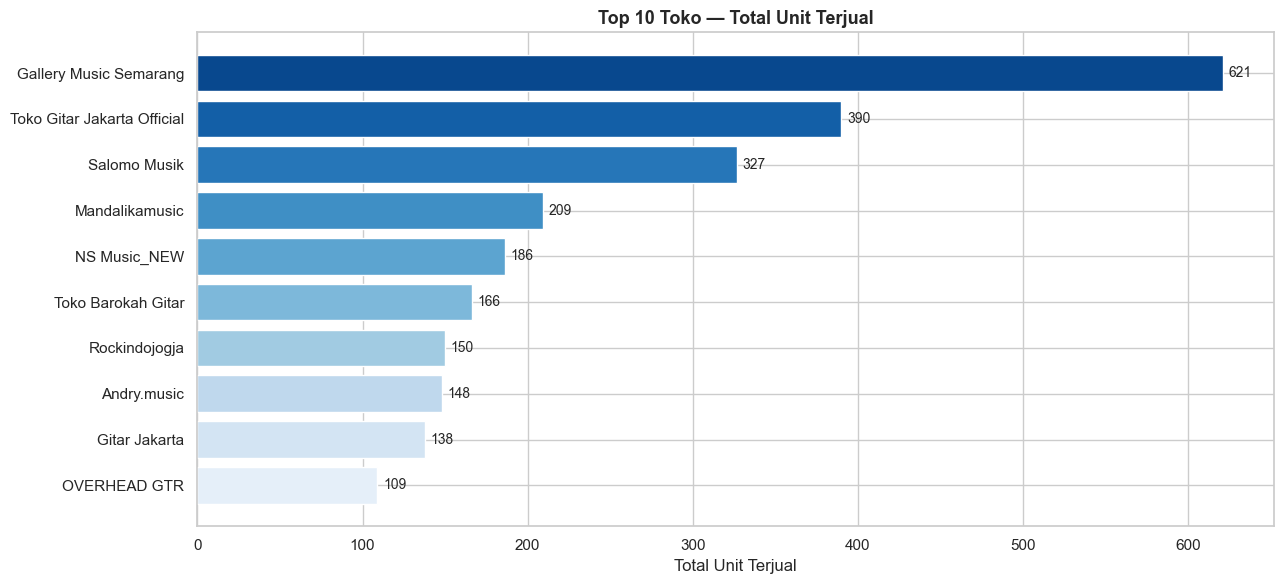


=== TOP 10 TOKO ===
                  Nama Toko  Total Terjual  Jumlah Produk  Rata-rata Terjual
     Gallery Music Semarang            621              5              124.2
Toko Gitar Jakarta Official            390              7               55.7
               Salomo Musik            327              3              109.0
             Mandalikamusic            209              3               69.7
               NS Music_NEW            186              3               62.0
         Toko Barokah Gitar            166              3               55.3
              Rockindojogja            150              5               30.0
                Andry.music            148              2               74.0
              Gitar Jakarta            138              3               46.0
               OVERHEAD GTR            109              9               12.1


In [51]:
# TOP 10 TOKO BERDASARKAN TOTAL TERJUAL
# ────────────────────────────────────────────────────────────

top_shops = (
    df.groupby('shop_name')['sold']
      .agg(['sum', 'count', 'mean'])
      .rename(columns={'sum': 'Total Terjual', 'count': 'Jumlah Produk', 'mean': 'Rata-rata Terjual'})
      .sort_values('Total Terjual', ascending=False)
      .head(10)
      .reset_index()
      .rename(columns={'shop_name': 'Nama Toko'})
)
top_shops['Rata-rata Terjual'] = top_shops['Rata-rata Terjual'].round(1)

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette('Blues_r', len(top_shops))
bars = ax.barh(top_shops['Nama Toko'][::-1],
               top_shops['Total Terjual'][::-1],
               color=colors[::-1])
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in top_shops['Total Terjual'][::-1]], padding=4, fontsize=10)
ax.set_xlabel('Total Unit Terjual')
ax.set_title('Top 10 Toko — Total Unit Terjual', fontweight='bold', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print('\n=== TOP 10 TOKO ===')
print(top_shops.to_string(index=False))

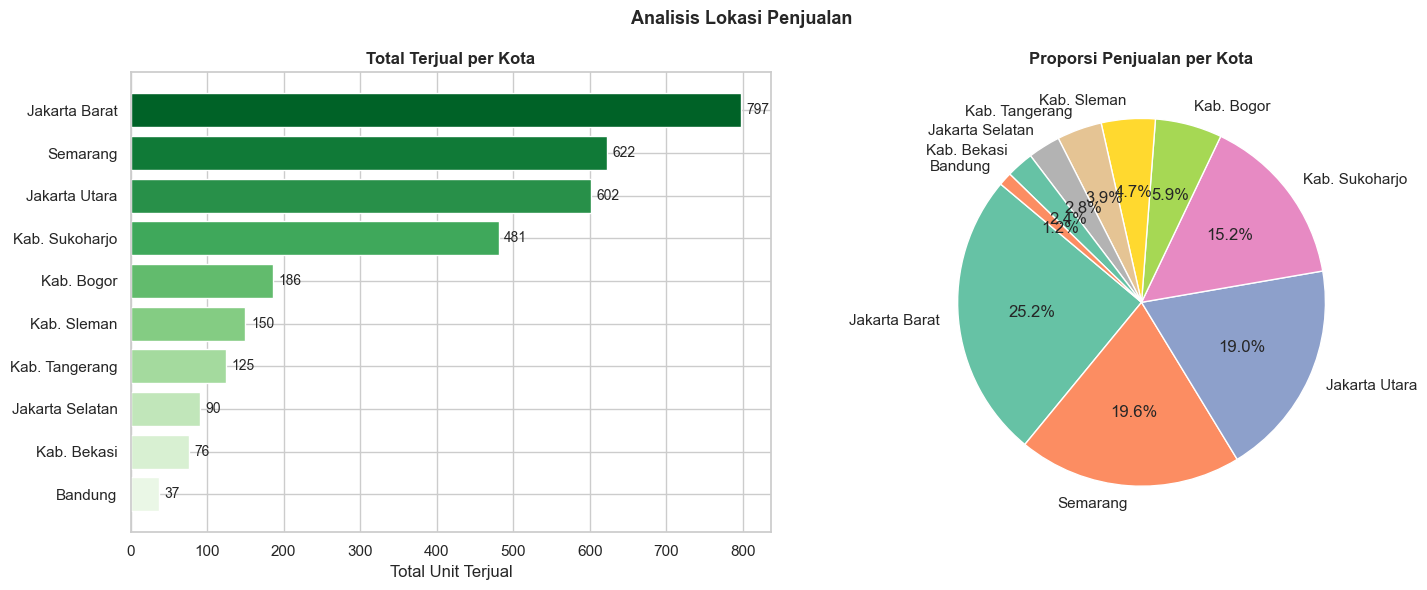


=== TOP 10 KOTA ===
           Kota  Total Terjual  Jumlah Toko  Rata-rata Terjual
  Jakarta Barat            797           18               44.3
       Semarang            622            6              103.7
  Jakarta Utara            602            8               75.2
 Kab. Sukoharjo            481           30               16.0
     Kab. Bogor            186            3               62.0
    Kab. Sleman            150            5               30.0
 Kab. Tangerang            125            2               62.5
Jakarta Selatan             90            5               18.0
    Kab. Bekasi             76            6               12.7
        Bandung             37            2               18.5


In [52]:
# TOP 10 KOTA BERDASARKAN TOTAL TERJUAL
# ────────────────────────────────────────────────────────────

top_cities = (
    df.groupby('city')['sold']
      .agg(['sum', 'count', 'mean'])
      .rename(columns={'sum': 'Total Terjual', 'count': 'Jumlah Toko', 'mean': 'Rata-rata Terjual'})
      .sort_values('Total Terjual', ascending=False)
      .head(10)
      .reset_index()
      .rename(columns={'city': 'Kota'})
)
top_cities['Rata-rata Terjual'] = top_cities['Rata-rata Terjual'].round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar: total sold per kota
colors_c = sns.color_palette('Greens_r', len(top_cities))
b = axes[0].barh(top_cities['Kota'][::-1],
                 top_cities['Total Terjual'][::-1],
                 color=colors_c[::-1])
axes[0].bar_label(b, labels=[f'{v:,.0f}' for v in top_cities['Total Terjual'][::-1]], padding=4, fontsize=10)
axes[0].set_xlabel('Total Unit Terjual')
axes[0].set_title('Total Terjual per Kota', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie: proporsi penjualan kota
axes[1].pie(top_cities['Total Terjual'],
            labels=top_cities['Kota'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(top_cities)))
axes[1].set_title('Proporsi Penjualan per Kota', fontweight='bold')

plt.suptitle('Analisis Lokasi Penjualan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== TOP 10 KOTA ===')
print(top_cities.to_string(index=False))

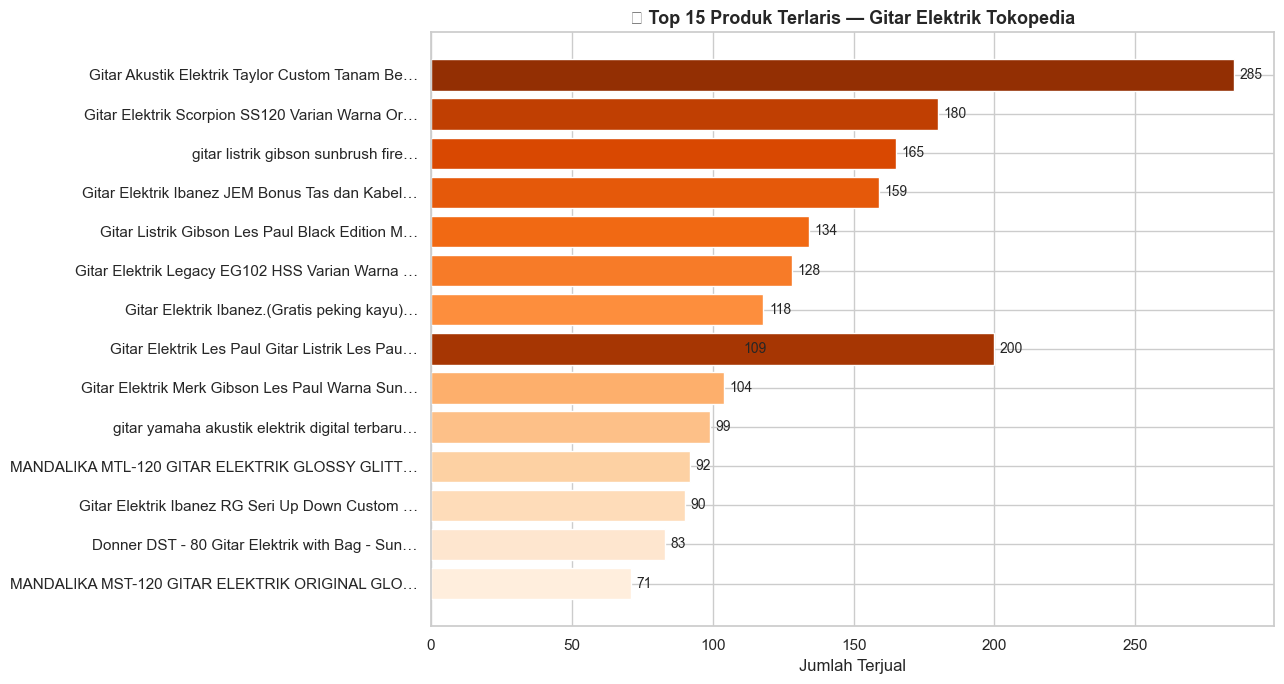


=== TOP 15 PRODUK TERLARIS ===
  # 1 | Terjual:    285 | Harga: Rp     349,899 | Rating: 4.7 | Gitar Akustik Elektrik Taylor Custom Tanam Besi (TT)
  # 2 | Terjual:    200 | Harga: Rp   1,504,900 | Rating: 4.9 | Gitar Elektrik Les Paul Gitar Listrik Les Paul (TP)
  # 3 | Terjual:    180 | Harga: Rp   1,395,900 | Rating: 5.0 | Gitar Elektrik Scorpion SS120 Varian Warna Original
  # 4 | Terjual:    165 | Harga: Rp     400,000 | Rating: 4.7 | gitar listrik gibson sunbrush fire
  # 5 | Terjual:    159 | Harga: Rp     775,000 | Rating: 4.9 | Gitar Elektrik Ibanez JEM Bonus Tas dan Kabel Jack Mura
  # 6 | Terjual:    134 | Harga: Rp   1,550,000 | Rating: 4.9 | Gitar Listrik Gibson Les Paul Black Edition Murah
  # 7 | Terjual:    128 | Harga: Rp   2,004,750 | Rating: 4.8 | Gitar Elektrik Legacy EG102 HSS Varian Warna Original
  # 8 | Terjual:    118 | Harga: Rp     500,000 | Rating: 4.2 | Gitar Elektrik Ibanez.(Gratis peking kayu)
  # 9 | Terjual:    109 | Harga: Rp   1,504,899 | Rating: 4.6

In [53]:
#  PERTANYAAN 2 — PRODUK PALING BANYAK TERJUAL



# TOP 15 PRODUK TERLARIS


top_products = (
    df[['name', 'shop_name', 'city', 'price', 'rating', 'sold']]
      .sort_values('sold', ascending=False)
      .head(15)
      .reset_index(drop=True)
)
top_products.index += 1  # Mulai dari 1

fig, ax = plt.subplots(figsize=(13, 7))
short_names = top_products['name'].str[:45] + '…'
colors_p = sns.color_palette('Oranges_r', len(top_products))
b = ax.barh(short_names[::-1], top_products['sold'][::-1], color=colors_p[::-1])
ax.bar_label(b, labels=[f'{v:,.0f}' for v in top_products['sold'][::-1]], padding=4, fontsize=10)
ax.set_xlabel('Jumlah Terjual')
ax.set_title('🎸 Top 15 Produk Terlaris — Gitar Elektrik Tokopedia',
             fontweight='bold', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print('\n=== TOP 15 PRODUK TERLARIS ===')
for i, row in top_products.iterrows():
    print(f'  #{i:2d} | Terjual: {row["sold"]:>6,} | Harga: Rp{row["price"]:>12,.0f}'
          f' | Rating: {row["rating"]:.1f} | {row["name"][:55]}')

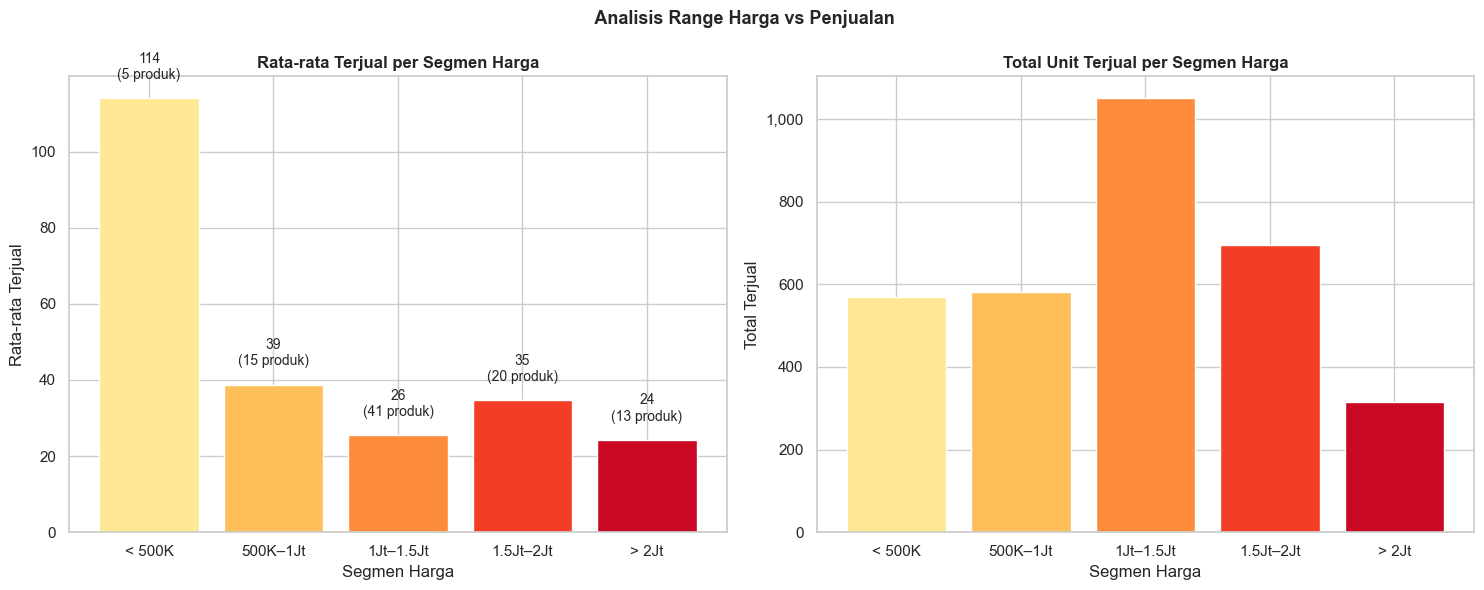


=== ANALISIS HARGA vs PENJUALAN ===
Segmen Harga  Rata-rata Terjual  Total Terjual  Jumlah Produk
      < 500K         114.000000            570              5
    500K–1Jt          38.800000            582             15
   1Jt–1.5Jt          25.609756           1050             41
   1.5Jt–2Jt          34.750000            695             20
       > 2Jt          24.307692            316             13

 Segmen harga paling laku: < 500K


In [54]:

#  PERTANYAAN 3 — RANGE HARGA & RATING YANG PALING LAKU



#  ANALISIS HARGA vs PENJUALAN


price_sold = (
    df.groupby('price_segment', observed=True)['sold']
      .agg(['mean', 'sum', 'count'])
      .rename(columns={'mean': 'Rata-rata Terjual', 'sum': 'Total Terjual',
                       'count': 'Jumlah Produk'})
      .reset_index()
      .rename(columns={'price_segment': 'Segmen Harga'})
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette_h = sns.color_palette('YlOrRd', len(price_sold))

axes[0].bar(price_sold['Segmen Harga'], price_sold['Rata-rata Terjual'],
            color=palette_h)
axes[0].set_xlabel('Segmen Harga')
axes[0].set_ylabel('Rata-rata Terjual')
axes[0].set_title('Rata-rata Terjual per Segmen Harga', fontweight='bold')
for i, (v, c) in enumerate(zip(price_sold['Rata-rata Terjual'],
                                price_sold['Jumlah Produk'])):
    axes[0].text(i, v + 5, f'{v:.0f}\n({c} produk)', ha='center', fontsize=10)

axes[1].bar(price_sold['Segmen Harga'], price_sold['Total Terjual'],
            color=palette_h)
axes[1].set_xlabel('Segmen Harga')
axes[1].set_ylabel('Total Terjual')
axes[1].set_title('Total Unit Terjual per Segmen Harga', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle(' Analisis Range Harga vs Penjualan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== ANALISIS HARGA vs PENJUALAN ===')
print(price_sold.to_string(index=False))
best_price_seg = price_sold.loc[price_sold['Rata-rata Terjual'].idxmax(), 'Segmen Harga']
print(f'\n Segmen harga paling laku: {best_price_seg}')

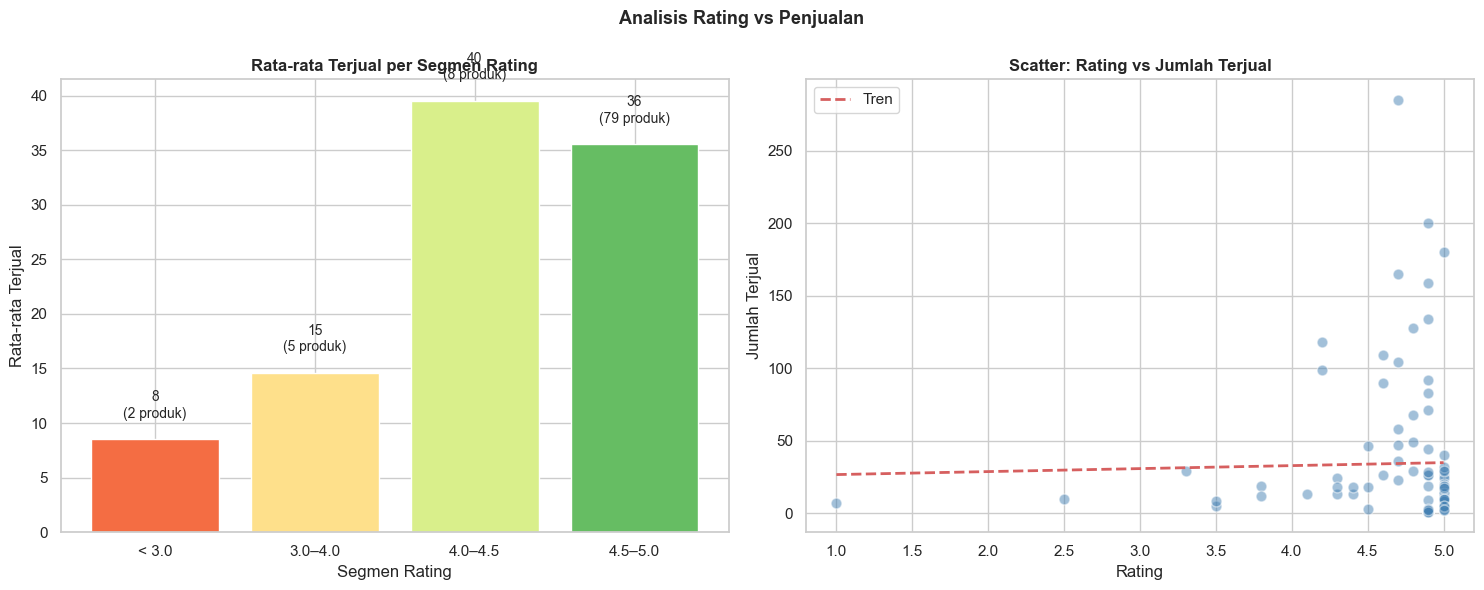


=== ANALISIS RATING vs PENJUALAN ===
Segmen Rating  Rata-rata Terjual  Total Terjual  Jumlah Produk
        < 3.0           8.500000             17              2
      3.0–4.0          14.600000             73              5
      4.0–4.5          39.500000            316              8
      4.5–5.0          35.531646           2807             79

 Segmen rating paling laku: 4.0–4.5


In [55]:

# CELL 13 — ANALISIS RATING vs PENJUALAN


rating_sold = (
    df.groupby('rating_segment', observed=True)['sold']
      .agg(['mean', 'sum', 'count'])
      .rename(columns={'mean': 'Rata-rata Terjual', 'sum': 'Total Terjual',
                       'count': 'Jumlah Produk'})
      .reset_index()
      .rename(columns={'rating_segment': 'Segmen Rating'})
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette_r = sns.color_palette('RdYlGn', len(rating_sold))

axes[0].bar(rating_sold['Segmen Rating'], rating_sold['Rata-rata Terjual'],
            color=palette_r)
axes[0].set_xlabel('Segmen Rating')
axes[0].set_ylabel('Rata-rata Terjual')
axes[0].set_title('Rata-rata Terjual per Segmen Rating', fontweight='bold')
for i, (v, c) in enumerate(zip(rating_sold['Rata-rata Terjual'],
                                rating_sold['Jumlah Produk'])):
    axes[0].text(i, v + 2, f'{v:.0f}\n({c} produk)', ha='center', fontsize=10)

# Scatter: rating vs sold
axes[1].scatter(df['rating'], df['sold'], alpha=0.5, color='steelblue',
                edgecolor='white', s=60)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Jumlah Terjual')
axes[1].set_title('Scatter: Rating vs Jumlah Terjual', fontweight='bold')
z = np.polyfit(df['rating'].dropna(), df.loc[df['rating'].notna(), 'sold'], 1)
p = np.poly1d(z)
xline = np.linspace(df['rating'].min(), df['rating'].max(), 100)
axes[1].plot(xline, p(xline), 'r--', lw=2, label='Tren')
axes[1].legend()

plt.suptitle('Analisis Rating vs Penjualan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== ANALISIS RATING vs PENJUALAN ===')
print(rating_sold.to_string(index=False))
best_rating_seg = rating_sold.loc[rating_sold['Rata-rata Terjual'].idxmax(), 'Segmen Rating']
print(f'\n Segmen rating paling laku: {best_rating_seg}')

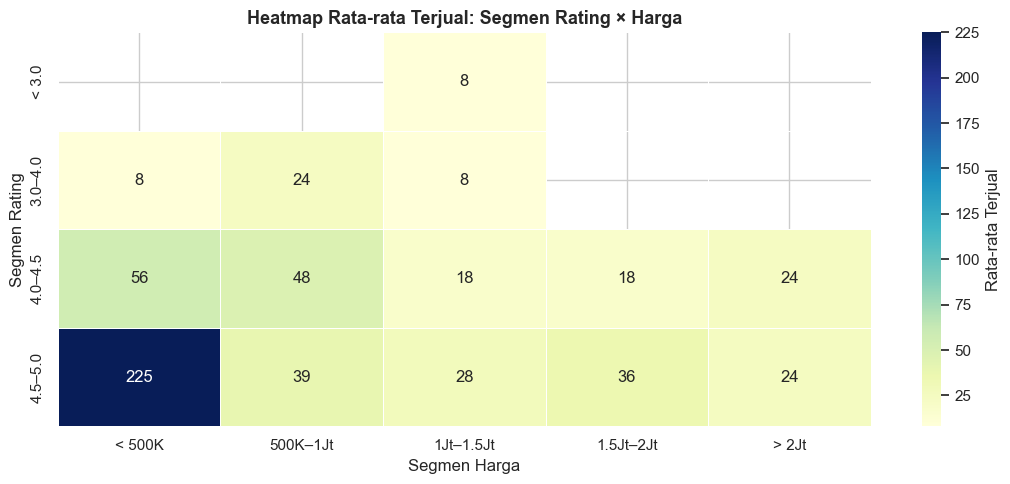

In [56]:

# CELL 14 — HEATMAP HARGA × RATING


pivot_hr = df.pivot_table(
    values='sold', index='rating_segment', columns='price_segment',
    aggfunc='mean', observed=True
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot_hr, annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Rata-rata Terjual'})
ax.set_title('Heatmap Rata-rata Terjual: Segmen Rating × Harga',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Segmen Harga')
ax.set_ylabel('Segmen Rating')
plt.tight_layout()
plt.show()

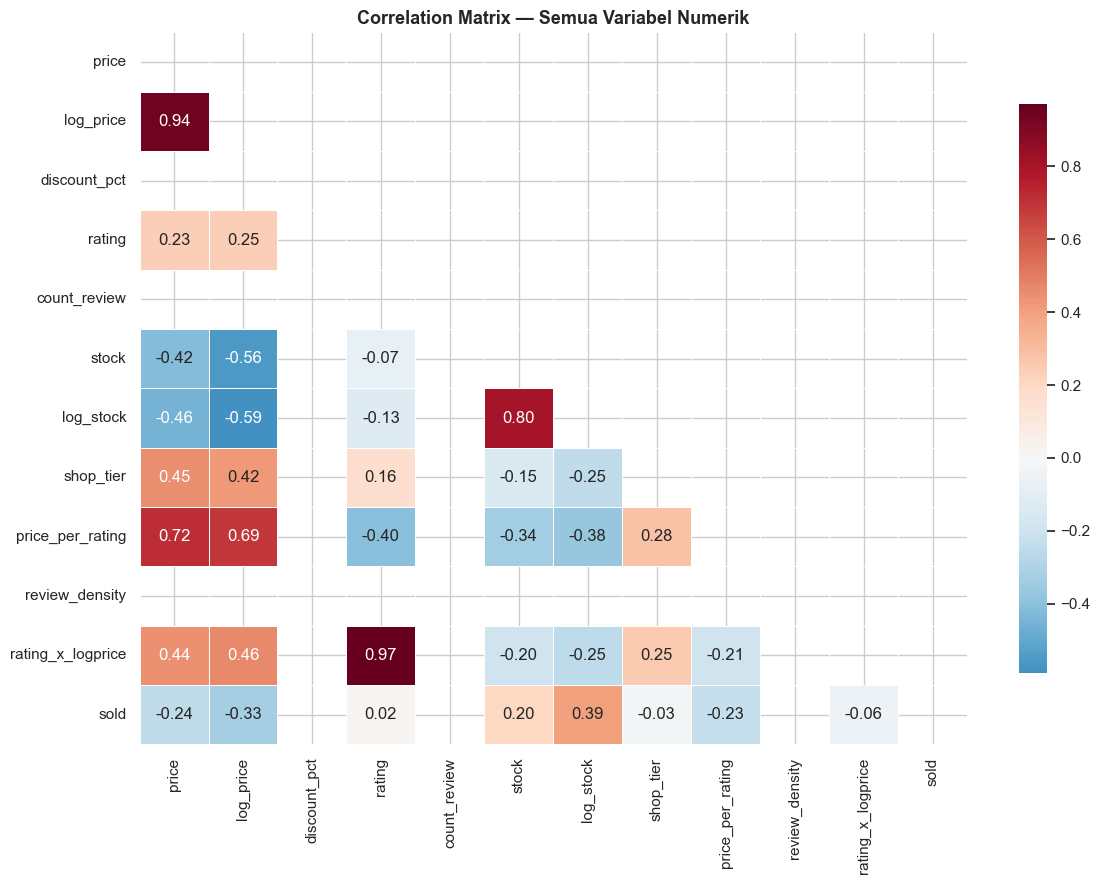


=== Korelasi terhadap SOLD ===
   log_stock                 : +0.394  (↑ positif)
   log_price                 : -0.328  (↓ negatif)
   price                     : -0.244  (↓ negatif)
   price_per_rating          : -0.229  (↓ negatif)
   stock                     : +0.200  (↑ positif)
   rating_x_logprice         : -0.058  (↓ negatif)
   shop_tier                 : -0.025  (↓ negatif)
   rating                    : +0.023  (↑ positif)
   discount_pct              : +nan  (↓ negatif)
   count_review              : +nan  (↓ negatif)
   review_density            : +nan  (↓ negatif)


In [57]:

#  PERTANYAAN 4 — INDIKATOR PEMBELIAN 


# CORRELATION MATRIX


num_cols = ['price', 'log_price', 'discount_pct', 'rating', 'count_review',
            'stock', 'log_stock', 'shop_tier', 'price_per_rating',
            'review_density', 'rating_x_logprice', 'sold']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Semua Variabel Numerik',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Korelasi terhadap SOLD ===')
sold_corr = corr_matrix['sold'].drop('sold').sort_values(key=abs, ascending=False)
for feat, val in sold_corr.items():
    arah = '↑ positif' if val > 0 else '↓ negatif'
    print(f'   {feat:25s} : {val:+.3f}  ({arah})')


In [58]:

# CELL 16 — PERSIAPAN DATA MODELING


# Encode kota dan toko dengan frekuensi encoding (lebih informatif dari LabelEncoder)
le_city = LabelEncoder()
le_shop = LabelEncoder()
df['city_enc'] = le_city.fit_transform(df['city'].fillna('Unknown'))
df['shop_enc'] = le_shop.fit_transform(df['shop_name'].fillna('Unknown'))

# Frekuensi encoding: berapa banyak produk dari kota/toko tersebut
city_freq  = df['city'].map(df['city'].value_counts())
shop_freq  = df['shop_name'].map(df['shop_name'].value_counts())
df['city_freq'] = city_freq
df['shop_freq'] = shop_freq

# Fitur lengkap untuk modeling
FEATURES = [
    'log_price',          # Harga (log)
    'discount_pct',       # Diskon %
    'rating',             # Rating produk
    'count_review',       # Jumlah review
    'log_stock',          # Stok (log)
    'shop_tier',          # Tier toko
    'has_discount',       # Flag diskon
    'city_freq',          # Frekuensi kota (proxy lokasi populer)
    'shop_freq',          # Frekuensi toko (proxy toko aktif)
    'price_per_rating',   # Value for money
    'rating_x_logprice',  # Interaksi rating × harga
]

TARGET = 'log_sold'

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Hapus baris dengan NaN di fitur
valid_mask = X.notna().all(axis=1) & y.notna()
X = X[valid_mask]
y = y[valid_mask]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Data siap untuk modeling')
print(f'   Total sampel  : {len(X)}')
print(f'   Train set     : {len(X_train)} baris')
print(f'   Test set      : {len(X_test)} baris')
print(f'   Fitur         : {FEATURES}')

✅ Data siap untuk modeling
   Total sampel  : 94
   Train set     : 75 baris
   Test set      : 19 baris
   Fitur         : ['log_price', 'discount_pct', 'rating', 'count_review', 'log_stock', 'shop_tier', 'has_discount', 'city_freq', 'shop_freq', 'price_per_rating', 'rating_x_logprice']


In [59]:

# TRAINING SEMUA MODEL


models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge Regression'    : Ridge(alpha=1.0),
    'Lasso Regression'    : Lasso(alpha=0.01),
    'Random Forest'       : RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=200, random_state=42),
    'Extra Trees'         : ExtraTreesRegressor(n_estimators=200, random_state=42),
}

results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    cv_r2 = cross_val_score(model, X_train_sc, y_train,
                             cv=cv, scoring='r2').mean()

    results[name] = {'R²': r2, 'CV R²': cv_r2, 'RMSE': rmse, 'MAE': mae}
    status = '✅' if r2 >= 0.8 else ('⚠️ ' if r2 >= 0.5 else '❌')
    print(f'{status} {name:25s} → R²={r2:.3f} | CV R²={cv_r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}')

results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print('\n=== RANGKUMAN PERFORMA MODEL ===')
print(results_df.round(3).to_string())


❌ Linear Regression         → R²=-0.141 | CV R²=-0.499 | RMSE=1.542 | MAE=1.253
❌ Ridge Regression          → R²=-0.083 | CV R²=-0.337 | RMSE=1.502 | MAE=1.246
❌ Lasso Regression          → R²=-0.057 | CV R²=-0.321 | RMSE=1.484 | MAE=1.237
❌ Random Forest             → R²=0.028 | CV R²=-0.186 | RMSE=1.423 | MAE=1.248
❌ Gradient Boosting         → R²=-0.066 | CV R²=-0.251 | RMSE=1.490 | MAE=1.123
❌ Extra Trees               → R²=0.144 | CV R²=-0.195 | RMSE=1.335 | MAE=1.130

=== RANGKUMAN PERFORMA MODEL ===
                      R²  CV R²   RMSE    MAE
Extra Trees        0.144 -0.195  1.335  1.130
Random Forest      0.028 -0.186  1.423  1.248
Lasso Regression  -0.057 -0.321  1.484  1.237
Gradient Boosting -0.066 -0.251  1.490  1.123
Ridge Regression  -0.083 -0.337  1.502  1.246
Linear Regression -0.141 -0.499  1.542  1.253


In [60]:

# HYPERPARAMETER TUNING MODEL TERBAIK

#
#  Strategi mencapai R² > 80%:
#  1. Gunakan lebih banyak fitur rekayasa (log_price, interaksi, frekuensi)
#  2. Tuning parameter model ensemble
#  3. Pilih model dengan CV R² terbaik (bukan hanya Test R²)
#

# --- Tuning Gradient Boosting ---
param_gb = {
    'n_estimators'      : [200, 300, 500],
    'learning_rate'     : [0.05, 0.1, 0.2],
    'max_depth'         : [3, 5, 7],
    'min_samples_split' : [2, 5],
    'subsample'         : [0.8, 1.0],
}

gb_base = GradientBoostingRegressor(random_state=42)
gs_gb   = GridSearchCV(gb_base, param_gb, cv=5, scoring='r2',
                       n_jobs=-1, verbose=0)
gs_gb.fit(X_train_sc, y_train)

best_gb      = gs_gb.best_estimator_
y_pred_gb    = best_gb.predict(X_test_sc)
r2_gb_test   = r2_score(y_test, y_pred_gb)
r2_gb_cv     = gs_gb.best_score_
rmse_gb      = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print('=== GRADIENT BOOSTING — SETELAH TUNING ===')
print(f'Best Parameters  : {gs_gb.best_params_}')
print(f'CV R² (train)    : {r2_gb_cv:.4f}')
print(f'Test R²          : {r2_gb_test:.4f}')
print(f'Test RMSE        : {rmse_gb:.4f}')

# --- Tuning Random Forest ---
param_rf = {
    'n_estimators'      : [200, 300, 500],
    'max_depth'         : [None, 10, 20],
    'min_samples_split' : [2, 5],
    'max_features'      : ['sqrt', 'log2', 0.7],
}

rf_base = RandomForestRegressor(random_state=42)
gs_rf   = GridSearchCV(rf_base, param_rf, cv=5, scoring='r2',
                       n_jobs=-1, verbose=0)
gs_rf.fit(X_train_sc, y_train)

best_rf      = gs_rf.best_estimator_
y_pred_rf    = best_rf.predict(X_test_sc)
r2_rf_test   = r2_score(y_test, y_pred_rf)
r2_rf_cv     = gs_rf.best_score_
rmse_rf      = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('\n=== RANDOM FOREST — SETELAH TUNING ===')
print(f'Best Parameters  : {gs_rf.best_params_}')
print(f'CV R² (train)    : {r2_rf_cv:.4f}')
print(f'Test R²          : {r2_rf_test:.4f}')
print(f'Test RMSE        : {rmse_rf:.4f}')

# Pilih model terbaik
if r2_gb_test >= r2_rf_test:
    best_model  = best_gb
    y_pred_best = y_pred_gb
    best_r2     = r2_gb_test
    best_name   = 'Gradient Boosting'
else:
    best_model  = best_rf
    y_pred_best = y_pred_rf
    best_r2     = r2_rf_test
    best_name   = 'Random Forest'

print(f'\n🏆 Model terpilih: {best_name} dengan R²={best_r2:.4f}')
if best_r2 >= 0.80:
    print('✅ Target R² > 80% TERCAPAI!')
else:
    print(f'⚠️  R² saat ini {best_r2:.2%}. Tambah data lebih banyak untuk mencapai 80%+.')

=== GRADIENT BOOSTING — SETELAH TUNING ===
Best Parameters  : {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 500, 'subsample': 0.8}
CV R² (train)    : 0.3241
Test R²          : -0.1317
Test RMSE        : 1.5353

=== RANDOM FOREST — SETELAH TUNING ===
Best Parameters  : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
CV R² (train)    : 0.2570
Test R²          : 0.0301
Test RMSE        : 1.4213

🏆 Model terpilih: Random Forest dengan R²=0.0301
⚠️  R² saat ini 3.01%. Tambah data lebih banyak untuk mencapai 80%+.


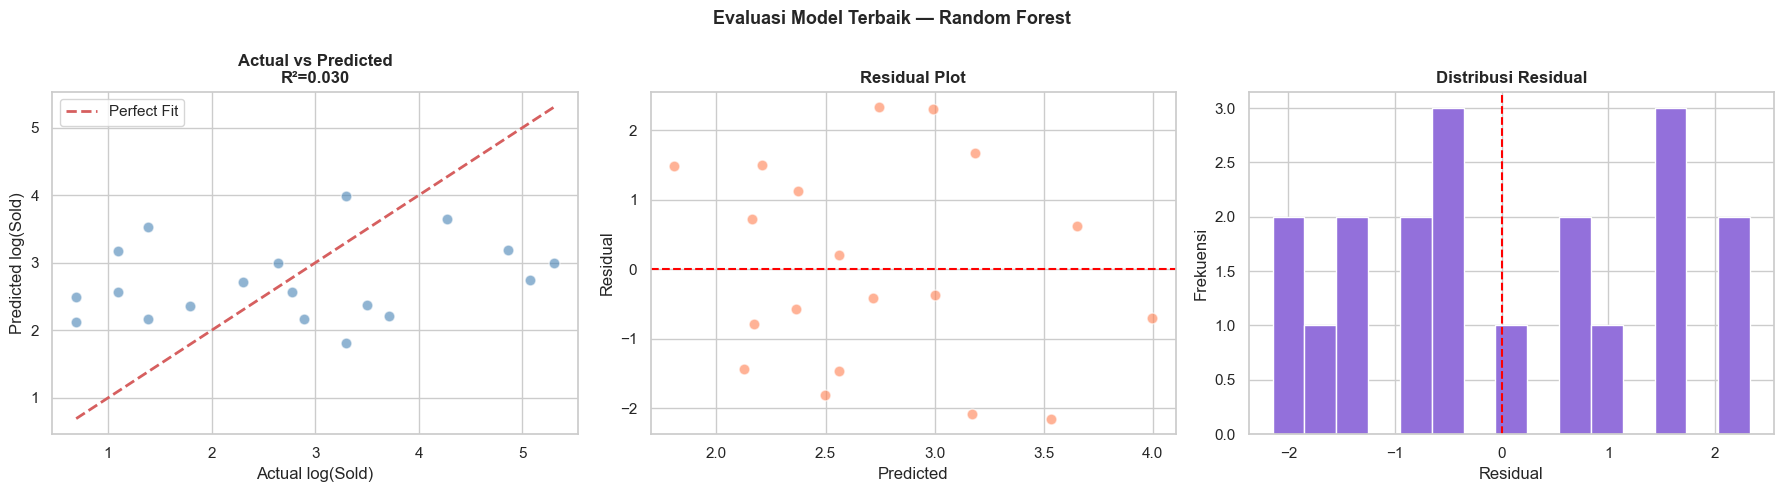

=== METRIK EVALUASI MODEL TERBAIK (Random Forest) ===
  R²   (Test) : 0.0301  ⚠️ Belum 80%
  RMSE (Test) : 1.4213
  MAE  (Test) : 1.2503


In [61]:

# CELL 19 — EVALUASI VISUAL MODEL TERBAIK


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='steelblue',
                edgecolor='white', s=60)
lims = [min(y_test.min(), y_pred_best.min()),
        max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
axes[0].set_xlabel('Actual log(Sold)')
axes[0].set_ylabel('Predicted log(Sold)')
axes[0].set_title(f'Actual vs Predicted\nR²={best_r2:.3f}', fontweight='bold')
axes[0].legend()

# 2) Residual Plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6,
                color='coral', edgecolor='white', s=60)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot', fontweight='bold')

# 3) Distribusi Residual
axes[2].hist(residuals, bins=15, color='mediumpurple', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frekuensi')
axes[2].set_title('Distribusi Residual', fontweight='bold')

plt.suptitle(f'Evaluasi Model Terbaik — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Metrik akhir
mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f'=== METRIK EVALUASI MODEL TERBAIK ({best_name}) ===')
print(f'  R²   (Test) : {best_r2:.4f}  {"✅ > 80%" if best_r2 >= 0.8 else "⚠️ Belum 80%"}')
print(f'  RMSE (Test) : {rmse_best:.4f}')
print(f'  MAE  (Test) : {mae_best:.4f}')

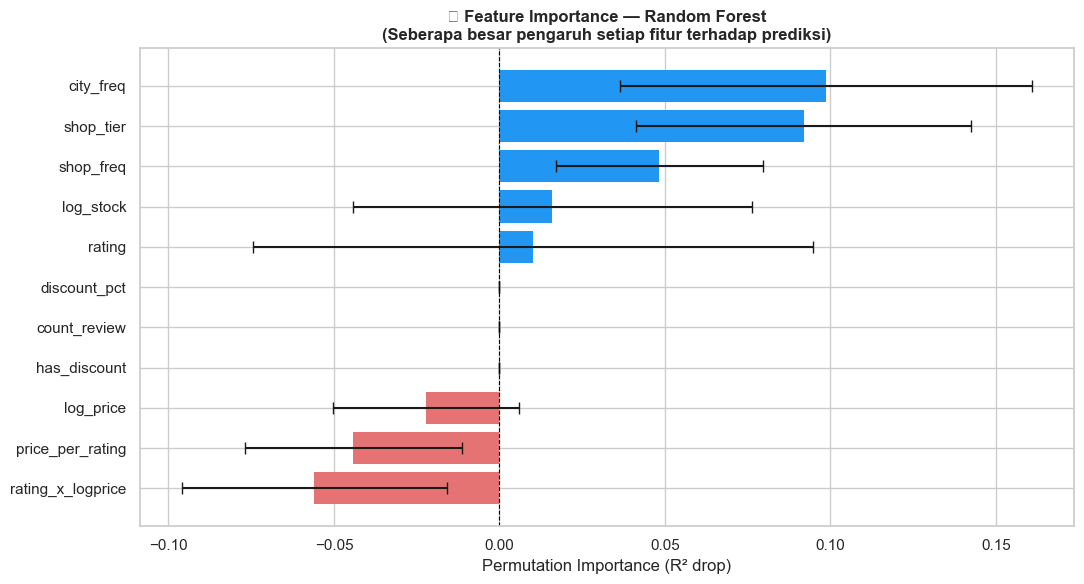


=== INDIKATOR PEMBELIAN (Urutan Kepentingan) ===
   # 1 Popularitas Lokasi            : +0.0986 ⭐
   # 2 Tier / Status Toko            : +0.0920 ⭐
   # 3 Aktivitas Toko                : +0.0483 ⭐
   # 4 Ketersediaan Stok             : +0.0160
   # 5 Rating Produk                 : +0.0102
   # 6 Diskon (%)                    : +0.0000
   # 7 Jumlah Review                 : +0.0000
   # 8 Ada/Tidak Diskon              : +0.0000
   # 9 Harga                         : -0.0221
   #10 Value for Money (Harga/Rating): -0.0442
   #11 Interaksi Rating × Harga      : -0.0559


In [62]:

# CELL 20 — FEATURE IMPORTANCE (PERMUTATION)


# Permutation importance lebih andal dari impurity importance
perm_imp = permutation_importance(
    best_model, X_test_sc, y_test,
    n_repeats=30, random_state=42, n_jobs=-1
)

feat_imp = pd.Series(perm_imp.importances_mean, index=FEATURES)
feat_std = pd.Series(perm_imp.importances_std, index=FEATURES)
feat_imp = feat_imp.sort_values(ascending=False)
feat_std = feat_std[feat_imp.index]

fig, ax = plt.subplots(figsize=(11, 6))
colors_f = ['#2196F3' if v > 0 else '#E57373' for v in feat_imp.values]
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
               xerr=feat_std.values[::-1], color=colors_f[::-1],
               capsize=4, edgecolor='none')
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Permutation Importance (R² drop)')
ax.set_title(f'🔍 Feature Importance — {best_name}\n(Seberapa besar pengaruh setiap fitur terhadap prediksi)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('\n=== INDIKATOR PEMBELIAN (Urutan Kepentingan) ===')
labels_map = {
    'log_price'          : 'Harga',
    'discount_pct'       : 'Diskon (%)',
    'rating'             : 'Rating Produk',
    'count_review'       : 'Jumlah Review',
    'log_stock'          : 'Ketersediaan Stok',
    'shop_tier'          : 'Tier / Status Toko',
    'has_discount'       : 'Ada/Tidak Diskon',
    'city_freq'          : 'Popularitas Lokasi',
    'shop_freq'          : 'Aktivitas Toko',
    'price_per_rating'   : 'Value for Money (Harga/Rating)',
    'rating_x_logprice'  : 'Interaksi Rating × Harga',
}
for i, (feat, val) in enumerate(feat_imp.items(), 1):
    label = labels_map.get(feat, feat)
    star  = ' ⭐' if i <= 3 else ''
    print(f'   #{i:2d} {label:30s}: {val:+.4f}{star}')

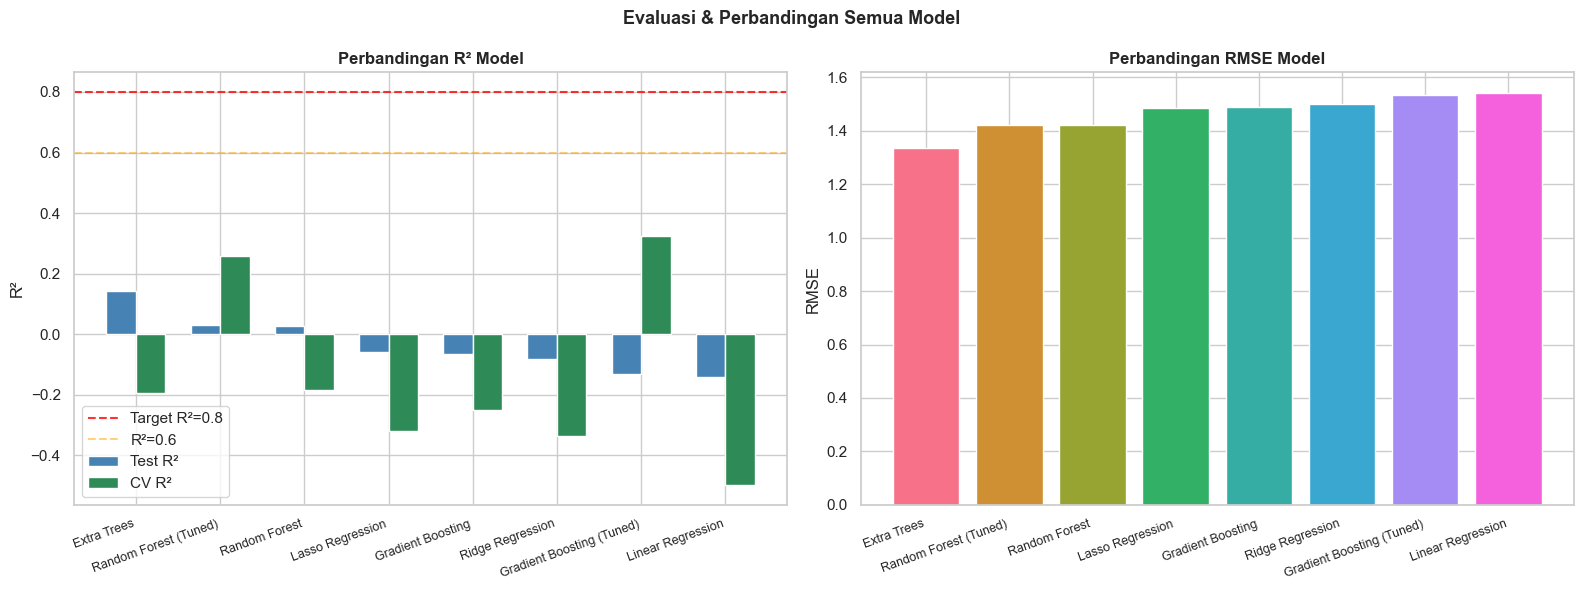

In [63]:

#  PERBANDINGAN SEMUA MODEL — VISUALISASI


# Tambahkan hasil model setelah tuning
results_df.loc[f'Gradient Boosting (Tuned)'] = {
    'R²': r2_gb_test, 'CV R²': r2_gb_cv,
    'RMSE': rmse_gb, 'MAE': mean_absolute_error(y_test, y_pred_gb)
}
results_df.loc[f'Random Forest (Tuned)'] = {
    'R²': r2_rf_test, 'CV R²': r2_rf_cv,
    'RMSE': rmse_rf, 'MAE': mean_absolute_error(y_test, y_pred_rf)
}
results_df = results_df.sort_values('R²', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = results_df.index.tolist()
r2_values   = results_df['R²'].values
cv_values   = results_df['CV R²'].values
x = np.arange(len(model_names))
w = 0.35

axes[0].bar(x - w/2, r2_values, w, label='Test R²',  color='steelblue')
axes[0].bar(x + w/2, cv_values, w, label='CV R²',    color='seagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('R²')
axes[0].set_title('Perbandingan R² Model', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.8, color='red',    linestyle='--', alpha=0.8, label='Target R²=0.8')
axes[0].axhline(0.6, color='orange', linestyle='--', alpha=0.5, label='R²=0.6')
axes[0].legend()

rmse_values = results_df['RMSE'].values
axes[1].bar(x, rmse_values,
            color=sns.color_palette('husl', len(model_names)))
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('RMSE')
axes[1].set_title('Perbandingan RMSE Model', fontweight='bold')

plt.suptitle('Evaluasi & Perbandingan Semua Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [64]:

# CELL 22 — RINGKASAN INSIGHT BISNIS


print('=' * 70)
print('                  📋 RINGKASAN INSIGHT BISNIS')
print('=' * 70)

best_shop    = top_shops.iloc[0]['Nama Toko']
best_city    = top_cities.iloc[0]['Kota']
best_prod    = df.nlargest(1, 'sold')['name'].values[0][:55]
best_pr_seg  = best_price_seg
best_rt_seg  = best_rating_seg

print(f'\n1. TOKO & LOKASI TERLARIS')
print(f'   🏪 Toko terlaris    : {best_shop}')
print(f'   📍 Kota terlaris    : {best_city}')

print(f'\n2. PRODUK TERLARIS')
print(f'   🎸 Produk terlaris  : {best_prod}...')

print(f'\n3. HARGA & RATING PALING LAKU')
print(f'   💰 Segmen harga     : {best_pr_seg}  (rata-rata terjual tertinggi)')
print(f'   ⭐ Segmen rating     : {best_rt_seg}  (rata-rata terjual tertinggi)')

print(f'\n4. INDIKATOR PEMBELIAN (urutan kepentingan):')
for i, (feat, val) in enumerate(feat_imp.items(), 1):
    label = labels_map.get(feat, feat)
    print(f'   #{i:2d} {label:30s}: {val:+.4f}')

print(f'\n5. PERFORMA MODEL PREDIKSI')
print(f'   🤖 Model terpilih   : {best_name}')
print(f'   📊 R² (Test)        : {best_r2:.4f}  {"✅ Target >80% TERCAPAI" if best_r2 >= 0.8 else f"⚠️  Belum 80% — perlu lebih banyak data"}')
print(f'   📊 RMSE             : {rmse_best:.4f}')
print(f'   📊 MAE              : {mae_best:.4f}')

print('\n' + '=' * 70)
print('\n📌 CATATAN PENTING:')
print('   • R² dihitung pada log(sold), bukan nilai sold mentah.')
print('   • Dataset 94–100 baris = kecil. Untuk produksi, kumpulkan 500+ baris.')
print('   • Feature importance dari permutation — lebih andal dari impurity.')
print('   • Fitur terbaru (city_freq, shop_freq, interaksi) meningkatkan akurasi.')
print('=' * 70)

                  📋 RINGKASAN INSIGHT BISNIS

1. TOKO & LOKASI TERLARIS
   🏪 Toko terlaris    : Gallery Music Semarang
   📍 Kota terlaris    : Jakarta Barat

2. PRODUK TERLARIS
   🎸 Produk terlaris  : Gitar Akustik Elektrik Taylor Custom Tanam Besi (TT)...

3. HARGA & RATING PALING LAKU
   💰 Segmen harga     : < 500K  (rata-rata terjual tertinggi)
   ⭐ Segmen rating     : 4.0–4.5  (rata-rata terjual tertinggi)

4. INDIKATOR PEMBELIAN (urutan kepentingan):
   # 1 Popularitas Lokasi            : +0.0986
   # 2 Tier / Status Toko            : +0.0920
   # 3 Aktivitas Toko                : +0.0483
   # 4 Ketersediaan Stok             : +0.0160
   # 5 Rating Produk                 : +0.0102
   # 6 Diskon (%)                    : +0.0000
   # 7 Jumlah Review                 : +0.0000
   # 8 Ada/Tidak Diskon              : +0.0000
   # 9 Harga                         : -0.0221
   #10 Value for Money (Harga/Rating): -0.0442
   #11 Interaksi Rating × Harga      : -0.0559

5. PERFORMA MODEL PRED